# Model 1 — Forecast Bias-Correction: In-Sample & Out-of-Sample Performance

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import evaluation

# ── Load predictions from parquet (generated by model1_forecast.py) ──
df_train = pd.read_parquet('checkpoints/model1_preds_train.parquet')
df_test = pd.read_parquet('checkpoints/model1_preds_test.parquet')

print(f'Train set: {len(df_train)} rows, {df_train.date.min().date()} to {df_train.date.max().date()}')
print(f'Test set:  {len(df_test)} rows, {df_test.date.min().date()} to {df_test.date.max().date()}')

Train set: 16739 rows, 2022-01-01 to 2024-04-16
Test set:  7300 rows, 2025-04-17 to 2026-04-16


## Overall Metrics: In-Sample (Train 2022-2024) vs Out-of-Sample (Test 2026)

In [2]:
train_metrics = evaluation.compute_metrics(df_train['y_true'].values, df_train['mu'].values)
test_metrics = evaluation.compute_metrics(df_test['y_true'].values, df_test['mu'].values)

metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    index=['In-Sample (Train 2022-2024)', 'Out-of-Sample (Test 2026)']
)
metrics_df.round(4)

,mae,rmse,bias,r2,corr,n
In-Sample (Train 2022-2024),1.0017,1.3902,-0.0639,0.9946,0.9973,16739
Out-of-Sample (Test 2026),1.2480,1.6551,-0.0117,0.9919,0.9960,7300


## Per-City Metrics (Out-of-Sample Test Set)

In [3]:
city_metrics = evaluation.metrics_by_city(df_test, y_true_col='y_true', y_pred_col='mu')
city_metrics.round(4)

,mae,rmse,bias,r2,corr,n,city,ticker
12,0.6971,0.9053,-0.1640,0.9969,0.9986,365,Las Vegas,KXHIGHTLV
16,0.9186,1.1301,0.4561,0.9935,0.9975,365,Phoenix,KXHIGHTPHX
15,0.9188,1.2135,-0.1010,0.9942,0.9972,365,Oklahoma City,KXHIGHTOKC
9,1.0106,1.3322,0.1385,0.9913,0.9958,365,Dallas,KXHIGHTDAL
14,1.0653,1.3600,-0.2828,0.9873,0.9940,365,New Orleans,KXHIGHTNOLA
7,1.0900,1.3985,-0.4062,0.9904,0.9956,365,Atlanta,KXHIGHTATL
13,1.1436,1.4896,-0.4877,0.9960,0.9982,365,Minneapolis,KXHIGHTMIN
0,1.1534,1.4874,-0.7057,0.9864,0.9949,365,Austin,KXHIGHAUS
5,1.1537,1.5277,0.0318,0.9937,0.9969,365,New York,KXHIGHNY
4,1.1804,1.4822,0.9047,0.9512,0.9850,365,Miami,KXHIGHMIA


## Calibration Check (Out-of-Sample Test Set)

,target_coverage,actual_coverage
0,0.50,0.4347
1,0.68,0.6034
2,0.80,0.7244
3,0.90,0.8330
4,0.95,0.8952
5,0.99,0.9604


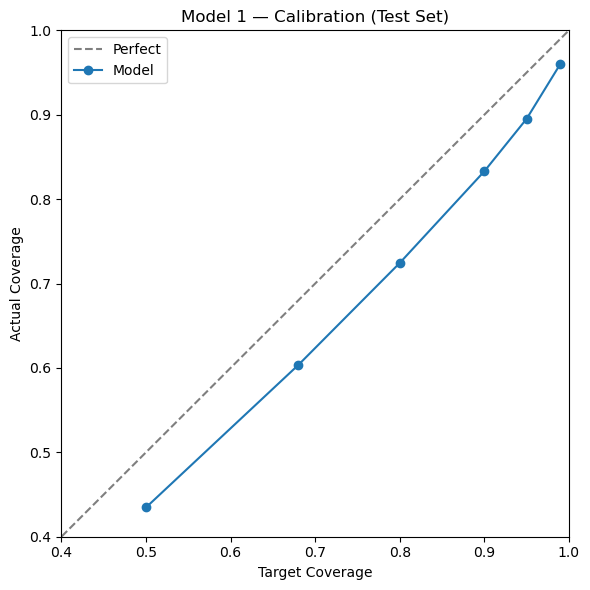

In [4]:
cal_df = evaluation.calibration_check(df_test['y_true'].values, df_test['mu'].values, df_test['sigma'].values)
display(cal_df.round(4))

fig = evaluation.plot_calibration(cal_df, title='Model 1 — Calibration (Test Set)')
plt.show()

## Residuals Histogram + Q-Q Plot

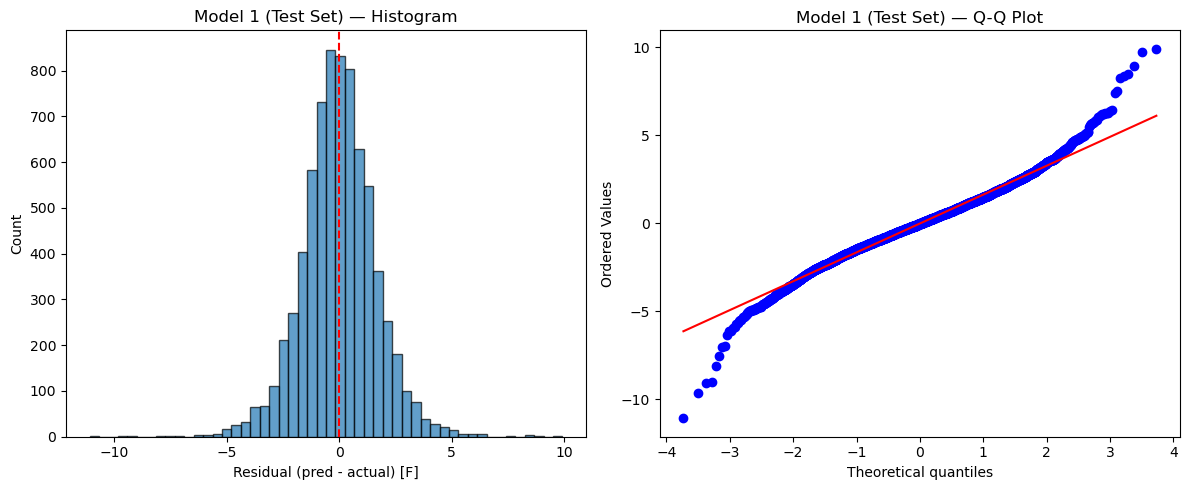

In [5]:
fig = evaluation.plot_residuals(df_test['y_true'].values, df_test['mu'].values, title='Model 1 (Test Set)')
plt.show()

## Time Series — NY, Phoenix, Miami

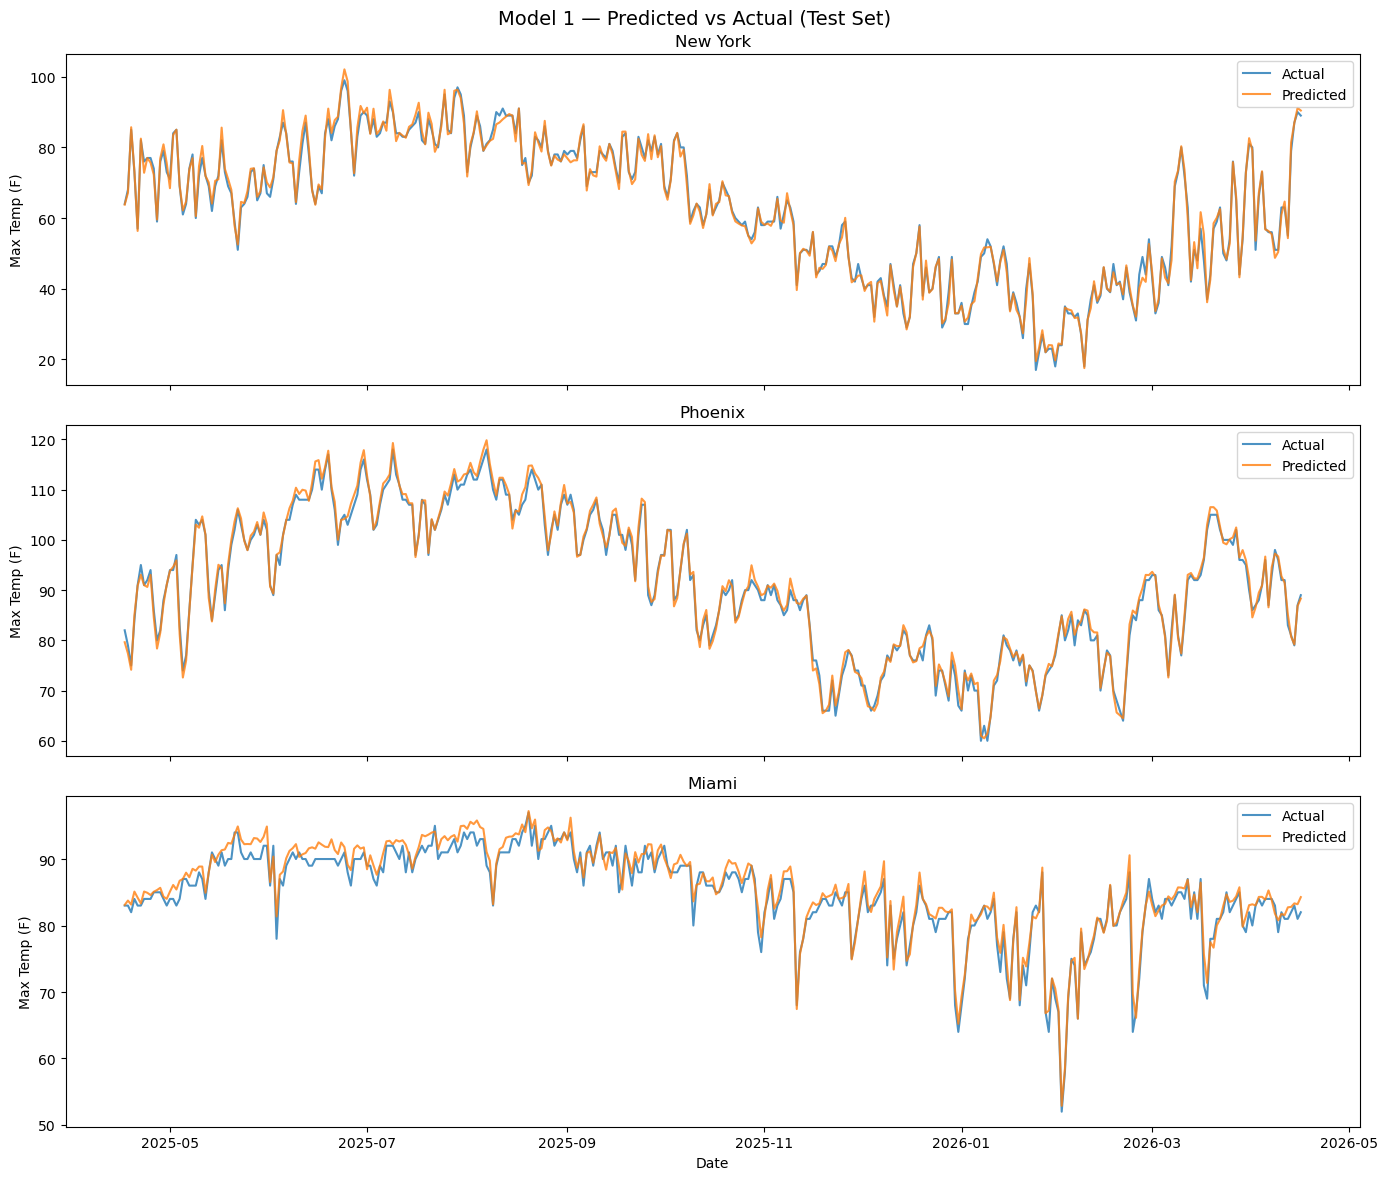

In [6]:
fig = evaluation.plot_timeseries(
    df_test, y_true_col='y_true', y_pred_col='mu',
    cities=['KXHIGHNY', 'KXHIGHTPHX', 'KXHIGHMIA'],
    title='Model 1 — Predicted vs Actual (Test Set)'
)
plt.show()

## MAE Heatmap by City and Month

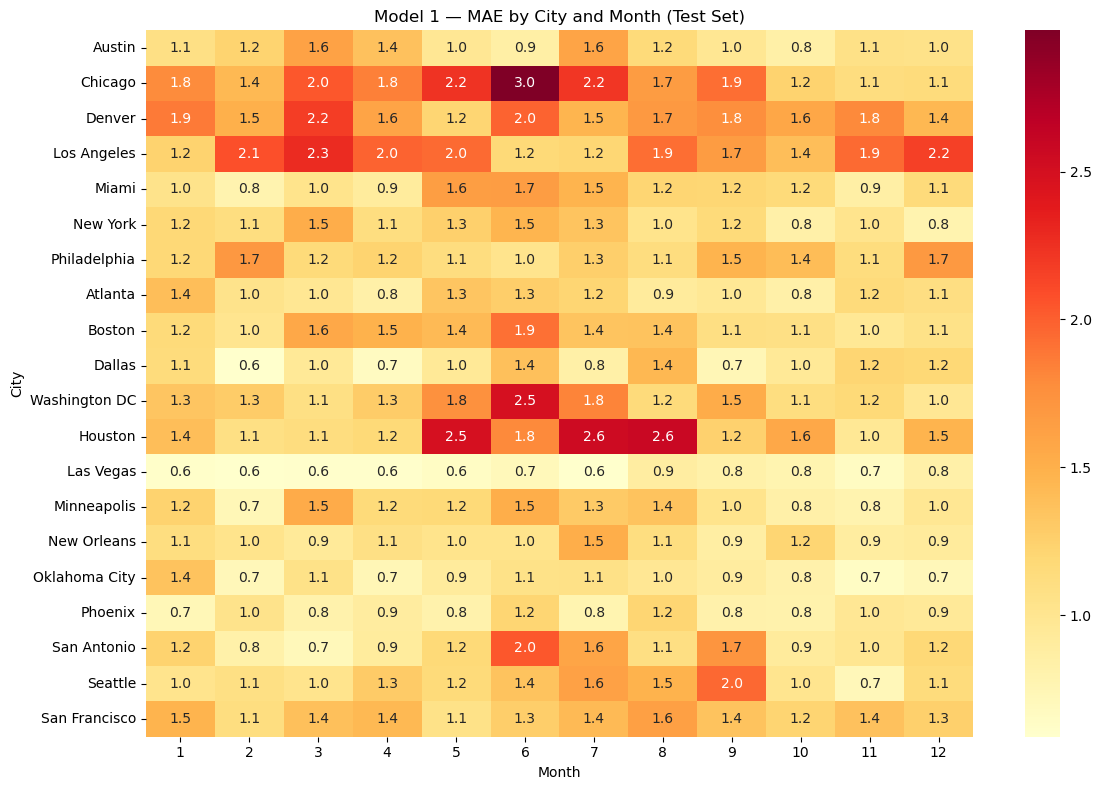

In [7]:
fig = evaluation.plot_mae_heatmap(
    df_test, y_true_col='y_true', y_pred_col='mu',
    title='Model 1 — MAE by City and Month (Test Set)'
)
plt.show()